# CS 4048 – Data Science (Fall 2025) · Project I
## Predicting Student Marks (Midterm I, Midterm II and Final Exam)

**Topics covered:** EDA · Preprocessing · Simple / Multiple / Polynomial Regression · K-fold CV · Bootstrapping · Dummy baseline

This notebook is written step by step so a beginner can follow it. Every section has a short explanation of **what** we do and **why**.

### Research questions
| RQ | Question | Target (what we predict) |
|---|---|---|
| RQ1 | How accurately can we predict **Midterm I** marks? | `mid1_pct` |
| RQ2 | How accurately can we predict **Midterm II** marks? | `mid2_pct` |
| RQ3 | How accurately can we predict **Final exam** marks? | `final_pct` |

### Table of contents
1. Setup and workflow diagram
2. Load and understand the raw data
3. Preprocessing (tidy, rescale, feature engineering, combine sheets)
4. Exploratory Data Analysis (EDA)
5. Train / test split (and how we avoid **data leakage**)
6. Modelling helpers (pipelines, K-fold CV, bootstrapping)
7. RQ1 · RQ2 · RQ3
8. Final summary and conclusions
9. Save deliverables

> **File needed:** put `marks_dataset.xlsx` in the same folder as this notebook.

## 1. Setup and workflow diagram

First we import the libraries. `pandas` handles tables, `matplotlib/seaborn` draw charts and `scikit-learn` gives us the regression models.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

RANDOM_STATE = 42          # same number => same results every time you run the notebook
DATA_FILE = "marks_dataset.xlsx"

### Workflow / pipeline diagram (Deliverable 4)
The diagram below shows **every step** of this project in order. Blue = data preparation, red = the split, green = modelling & evaluation.
The most important idea: **the split happens before anything is learned from the data** (imputation, scaling, model fitting are all done on the training part only). This is how we avoid *data leakage*.

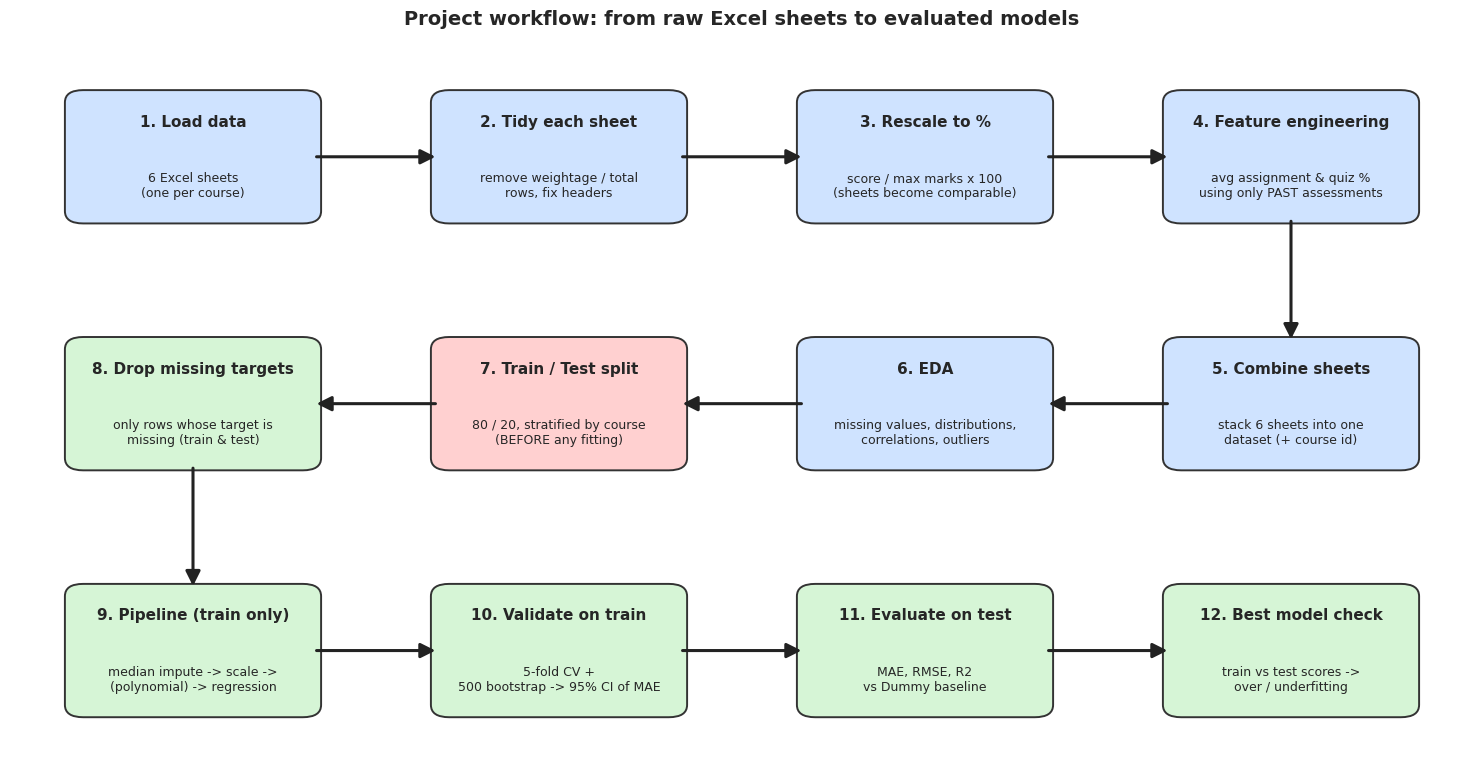

In [2]:
def draw_workflow(save_path=None):
    steps = [
        ("1. Load data",            "6 Excel sheets\n(one per course)",                  "#cfe3ff"),
        ("2. Tidy each sheet",      "remove weightage / total\nrows, fix headers",        "#cfe3ff"),
        ("3. Rescale to %",         "score / max marks x 100\n(sheets become comparable)", "#cfe3ff"),
        ("4. Feature engineering",  "avg assignment & quiz %\nusing only PAST assessments", "#cfe3ff"),
        ("5. Combine sheets",       "stack 6 sheets into one\ndataset (+ course id)",     "#cfe3ff"),
        ("6. EDA",                  "missing values, distributions,\ncorrelations, outliers", "#cfe3ff"),
        ("7. Train / Test split",   "80 / 20, stratified by course\n(BEFORE any fitting)", "#ffd0d0"),
        ("8. Drop missing targets", "only rows whose target is\nmissing (train & test)",   "#d6f5d6"),
        ("9. Pipeline (train only)","median impute -> scale ->\n(polynomial) -> regression", "#d6f5d6"),
        ("10. Validate on train",   "5-fold CV +\n500 bootstrap -> 95% CI of MAE",         "#d6f5d6"),
        ("11. Evaluate on test",    "MAE, RMSE, R2\nvs Dummy baseline",                    "#d6f5d6"),
        ("12. Best model check",    "train vs test scores ->\nover / underfitting",        "#d6f5d6"),
    ]
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.set_xlim(0, 4); ax.set_ylim(0, 3); ax.axis("off")
    pos = []
    for i in range(len(steps)):
        row, col = divmod(i, 4)
        if row % 2 == 1:           # snake layout: 2nd row goes right -> left
            col = 3 - col
        pos.append((col + 0.5, 2.5 - row))
    bw, bh = 0.66, 0.50
    for (x, y), (title, sub, color) in zip(pos, steps):
        ax.add_patch(FancyBboxPatch((x - bw/2, y - bh/2), bw, bh, boxstyle="round,pad=0.02,rounding_size=0.05",
                                    fc=color, ec="#333", lw=1.4))
        ax.text(x, y + 0.14, title, ha="center", va="center", fontsize=11, fontweight="bold")
        ax.text(x, y - 0.12, sub, ha="center", va="center", fontsize=9)
    for (x1, y1), (x2, y2) in zip(pos[:-1], pos[1:]):
        if y1 == y2:
            sx = x1 + (bw/2 if x2 > x1 else -bw/2); ex = x2 - (bw/2 if x2 > x1 else -bw/2)
            ax.annotate("", xy=(ex, y2), xytext=(sx, y1), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#222", mutation_scale=22))
        else:
            ax.annotate("", xy=(x2, y2 + bh/2), xytext=(x1, y1 - bh/2), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#222", mutation_scale=22))
    ax.set_title("Project workflow: from raw Excel sheets to evaluated models", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

draw_workflow("workflow_pipeline.png")

## 2. Load and understand the raw data

The Excel file has **6 sheets** (named `1` to `6`), one per course. Each sheet has a special layout:

* Row 1: column names (`As` = assignment, `Qz` = quiz, `S-I` = Midterm I, `S-II` = Midterm II, `Final`, `Proj` = project)
* Row 2: **Weightage** (how much each item counts in the course)
* Row 3: **Total** marks of each item
* Row 4: a `Sr.#` label row
* Row 5 onward: one row per student

Because the courses use different numbers of assessments and different totals, we **cannot** just stack the raw sheets together. First we look at them.

In [3]:
raw_sheets = pd.read_excel(DATA_FILE, sheet_name=None, header=None)   # dict: sheet name -> raw table
print("Sheets found:", list(raw_sheets.keys()))
print()
for name, sheet in raw_sheets.items():
    print(f"Sheet {name}: {sheet.shape[0]-4} students, {sheet.shape[1]-1} columns")

Sheets found: ['1', '2', '3', '4', '5', '6']

Sheet 1: 34 students, 20 columns
Sheet 2: 28 students, 20 columns
Sheet 3: 44 students, 20 columns
Sheet 4: 46 students, 18 columns
Sheet 5: 51 students, 24 columns
Sheet 6: 51 students, 24 columns


In [4]:
# Look at the first rows of sheet 1 exactly as it is in Excel
raw_sheets["1"].head(8)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,NaN,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-I,S-II:1,S-II,Final:1,Final
1,Weightage:,3,3,3,3,3,3,2,2,2,2,2,2,2,2,15,15,15,15,45,45
2,Total,130,70,90,50,120,90,5,15,10,10,10,5,12,2,40,NaN,40,NaN,100,NaN
3,Sr.#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,80.5,60.5,73.5,40.5,59,70.5,3.5,5,2,8,NaN,2.5,9,2,17.5,6.56,6.25,2.34,35.75,16.08
5,2,72.5,68,39,35,80.5,71,2.5,7,0,10,7,5,10,2,12.5,4.68,11,4.12,53.5,24.07
6,3,113,62,0,47,80,80,3.5,2.5,1,1,2,1,12,2,9.5,3.56,6.5,2.43,32.5,14.62
7,4,61,43.5,0,22,NaN,50,1.5,5,0.5,0,0,1,3,NaN,18.5,6.93,9,3.37,28,12.6


**What we notice**
* The first 4 rows are *descriptions* (names, weightage, total, label), **not students**.
* Some cells are empty (`NaN`). An empty cell means the mark is missing (e.g. absent / not recorded). A real zero is written as `0`, so we keep these two cases different.
* `S-I:1` is the raw midterm mark, while `S-I` is the *weighted* mark (e.g. out of 15). In sheets 5 and 6 the midterm is split into sub-questions (`S-I:1`, `S-I:2`, `S-I:3`), and `S-I` is their weighted total.
* Only sheet 3 has a project (`Proj`), so we will not use it (a feature that exists for 1 of 6 courses is not useful for a combined model).

## 3. Preprocessing

### 3.1 Tidy each sheet and convert everything to percentages
To make all courses comparable we express every score as a **percentage of its maximum**:

* Assignment / quiz: `mark / total_marks x 100`
* Midterm I, Midterm II, Final: `weighted_mark / weightage x 100` (this is the overall score of that exam, out of 100%)

This step works on one student row at a time using the *Total/Weightage* rows, so it does not use information from other students (no leakage).

In [5]:
def tidy_sheet(raw, sheet_name):
    """Turn one messy Excel sheet into a clean table where every score is a percentage (0-100)."""
    cols = raw.iloc[0].tolist()                      # row 1 = names
    weights = raw.iloc[1, 1:].astype(float)          # row 2 = weightage
    totals = raw.iloc[2, 1:]                         # row 3 = total marks
    weights.index = cols[1:]
    totals.index = cols[1:]

    data = raw.iloc[4:].copy()                       # real students start at row 5
    data.columns = ["sr"] + cols[1:]
    data = data.apply(pd.to_numeric, errors="coerce")  # make sure everything is a number
    data = data.dropna(subset=["sr"])                 # remove any empty trailing rows

    assign_cols = [c for c in cols if re.fullmatch(r"As:\d+", str(c))]
    quiz_cols   = [c for c in cols if re.fullmatch(r"Qz:\d+", str(c))]

    out = pd.DataFrame({"course": "C" + sheet_name, "student": data["sr"].astype(int)})

    # percentage of each assignment and quiz (kept in order: first assignment first)
    assign_pct = pd.DataFrame({c: data[c] / float(totals[c]) * 100 for c in assign_cols})
    quiz_pct   = pd.DataFrame({c: data[c] / float(totals[c]) * 100 for c in quiz_cols})

    # exams: weighted mark / weightage -> percentage
    out["mid1_pct"]  = data["S-I"]  / weights["S-I"]  * 100
    out["mid2_pct"]  = data["S-II"] / weights["S-II"] * 100
    out["final_pct"] = data["Final"] / weights["Final"] * 100
    return out.reset_index(drop=True), assign_pct.reset_index(drop=True), quiz_pct.reset_index(drop=True)

tidy = {name: tidy_sheet(sheet, name) for name, sheet in raw_sheets.items()}

# quick sanity check: no percentage should be below 0 or above 100
for name, (exams, a, q) in tidy.items():
    print(f"Sheet {name}: students={len(exams):2d} | assignments={a.shape[1]} | quizzes={q.shape[1]} | "
          f"max assign%={a.max().max():.1f} | max quiz%={q.max().max():.1f} | min any={min(a.min().min(), q.min().min()):.1f}")

Sheet 1: students=34 | assignments=6 | quizzes=8 | max assign%=100.0 | max quiz%=100.0 | min any=0.0
Sheet 2: students=28 | assignments=6 | quizzes=8 | max assign%=100.0 | max quiz%=100.0 | min any=0.0
Sheet 3: students=44 | assignments=5 | quizzes=7 | max assign%=100.0 | max quiz%=100.0 | min any=0.0
Sheet 4: students=46 | assignments=5 | quizzes=7 | max assign%=98.8 | max quiz%=100.0 | min any=0.0
Sheet 5: students=51 | assignments=4 | quizzes=6 | max assign%=100.0 | max quiz%=100.0 | min any=0.0
Sheet 6: students=51 | assignments=4 | quizzes=6 | max assign%=97.5 | max quiz%=100.0 | min any=0.0


### 3.2 Feature engineering – respecting the *timeline* (domain knowledge)
The assignment says: *using Midterm II to predict Midterm I is wrong*. We can only use information that **already exists** at the time we make the prediction.

The dataset has no dates, so we make a clear and simple assumption about a normal semester:

| Prediction | Assessments assumed to be finished before it | What we use |
|---|---|---|
| Midterm I | first **50%** of assignments and quizzes | `assign_avg_early`, `quiz_avg_early` |
| Midterm II | first **75%** of assignments and quizzes + **Midterm I** | `assign_avg_75`, `quiz_avg_75`, `mid1_pct` |
| Final exam | **all** assignments and quizzes + **Midterm I and II** | `assign_avg_all`, `quiz_avg_all`, `mid1_pct`, `mid2_pct` |

Each feature is the **average percentage** of those assessments. Averages skip empty cells, so a student with one missing quiz still gets a sensible average (this also handles most missing values without guessing).

In [6]:
def build_features(exams, assign_pct, quiz_pct):
    out = exams.copy()
    for label, frac in [("early", 0.50), ("75", 0.75), ("all", 1.00)]:
        k_a = int(np.ceil(assign_pct.shape[1] * frac))     # how many assignments count
        k_q = int(np.ceil(quiz_pct.shape[1] * frac))
        out[f"assign_avg_{label}"] = assign_pct.iloc[:, :k_a].mean(axis=1)   # mean() ignores NaN
        out[f"quiz_avg_{label}"]   = quiz_pct.iloc[:, :k_q].mean(axis=1)
    return out

course_tables = [build_features(*tidy[name]) for name in tidy]

### 3.3 Combine all sheets into one dataset
Now every sheet has the **same columns**, so we can stack them.

In [7]:
df = pd.concat(course_tables, ignore_index=True)
df.insert(0, "student_id", df["course"] + "_" + df["student"].astype(str))   # unique id like C1_5
df = df.drop(columns="student")
print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (254, 11)


,student_id,course,mid1_pct,mid2_pct,final_pct,assign_avg_early,quiz_avg_early,assign_avg_75,quiz_avg_75,assign_avg_all,quiz_avg_all
0,C1_1,C1,43.733333,15.600000,35.733333,76.672772,50.833333,72.036996,50.666667,73.086386,61.190476
1,C1_2,C1,31.200000,27.466667,53.488889,65.415140,49.166667,66.665751,61.111111,68.702941,68.750000
2,C1_3,C1,23.733333,16.200000,32.488889,58.498168,26.666667,67.232234,24.444444,70.841677,43.333333
3,C1_4,C1,46.200000,22.466667,28.000000,36.355311,17.083333,38.266484,14.722222,41.724298,16.190476
4,C1_5,C1,71.200000,43.733333,74.733333,85.423280,92.500000,89.253968,89.166667,91.044974,88.750000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        254 non-null    str    
 1   course            254 non-null    str    
 2   mid1_pct          254 non-null    float64
 3   mid2_pct          251 non-null    float64
 4   final_pct         254 non-null    float64
 5   assign_avg_early  252 non-null    float64
 6   quiz_avg_early    254 non-null    float64
 7   assign_avg_75     253 non-null    float64
 8   quiz_avg_75       254 non-null    float64
 9   assign_avg_all    253 non-null    float64
 10  quiz_avg_all      254 non-null    float64
dtypes: float64(9), str(2)
memory usage: 23.7 KB


## 4. Exploratory Data Analysis (EDA)

EDA means *looking* at the data before modelling. We only look here; **no number from this section is used to fill, scale or select anything** (that would risk leakage).

### 4.1 How many students per course? Any duplicates?

Duplicate student ids: 0
Duplicate full rows  : 0


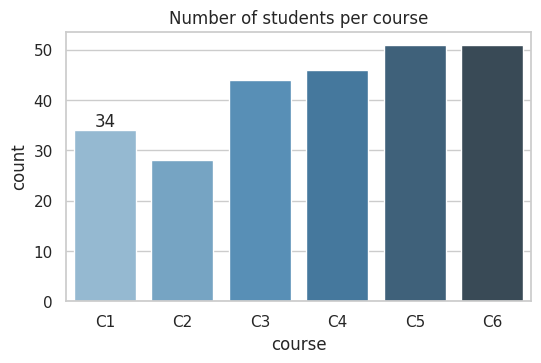

In [9]:
print("Duplicate student ids:", df["student_id"].duplicated().sum())
print("Duplicate full rows  :", df.drop(columns="student_id").duplicated().sum())

plt.figure(figsize=(6, 3.5))
ax = sns.countplot(data=df, x="course", palette="Blues_d")
ax.bar_label(ax.containers[0])
plt.title("Number of students per course")
plt.show()

### 4.2 Missing values

,missing_count,missing_%
mid2_pct,3,1.18
assign_avg_early,2,0.79
assign_avg_75,1,0.39
assign_avg_all,1,0.39


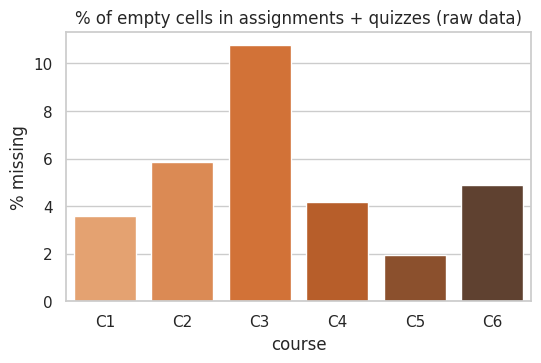

In [10]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_%"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing[missing["missing_count"] > 0])

# Missing cells in the ORIGINAL assignments/quizzes per course (before averaging)
rows = []
for name, (exams, a, q) in tidy.items():
    both = pd.concat([a, q], axis=1)
    rows.append({"course": "C" + name, "missing_%": both.isna().mean().mean() * 100})
miss_course = pd.DataFrame(rows)

plt.figure(figsize=(6, 3.5))
sns.barplot(data=miss_course, x="course", y="missing_%", palette="Oranges_d")
plt.title("% of empty cells in assignments + quizzes (raw data)")
plt.ylabel("% missing")
plt.show()

**Reading the result:** very few values are missing in the final table, because averaging already ignores empty cells. The only real gaps are `mid2_pct` (students who did not sit Midterm II) and a couple of averages of students with no marks in the early assessments. We handle these later (see Section 5).

### 4.3 Summary statistics

In [11]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
mid1_pct,254.0,44.79,17.18,3.73,31.67,45.00,56.20,93.33
mid2_pct,251.0,39.23,21.77,1.00,22.57,36.60,54.47,100.00
final_pct,254.0,44.25,19.12,5.45,31.74,43.44,57.28,91.76
assign_avg_early,252.0,60.30,20.09,0.00,49.31,61.90,76.51,97.61
quiz_avg_early,254.0,41.82,20.00,5.00,26.25,39.17,54.69,93.75
assign_avg_75,253.0,61.67,17.58,0.00,50.96,61.85,74.78,97.03
quiz_avg_75,254.0,41.76,19.25,3.75,26.67,38.42,56.00,94.45
assign_avg_all,253.0,62.90,16.65,0.00,52.94,62.63,75.60,97.75
quiz_avg_all,254.0,44.23,17.69,5.62,31.72,43.84,57.45,95.38


### 4.4 Distribution of the three targets (what we want to predict)

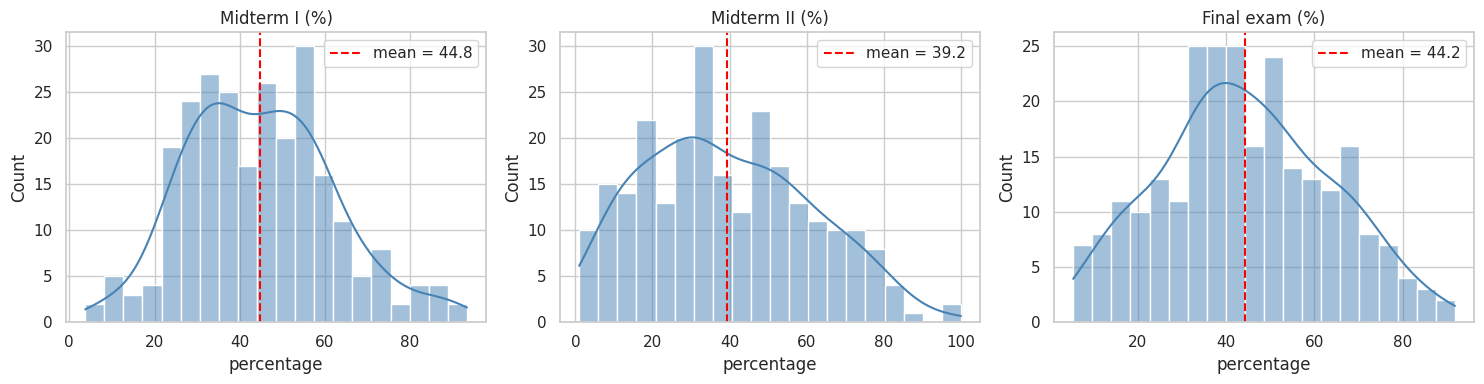

In [12]:
targets = ["mid1_pct", "mid2_pct", "final_pct"]
titles = {"mid1_pct": "Midterm I (%)", "mid2_pct": "Midterm II (%)", "final_pct": "Final exam (%)"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, targets):
    sns.histplot(df[t].dropna(), kde=True, bins=20, ax=ax, color="steelblue")
    ax.axvline(df[t].mean(), color="red", ls="--", label=f"mean = {df[t].mean():.1f}")
    ax.set_title(titles[t]); ax.set_xlabel("percentage"); ax.legend()
plt.tight_layout(); plt.show()

### 4.5 Do the courses differ? (box plots)

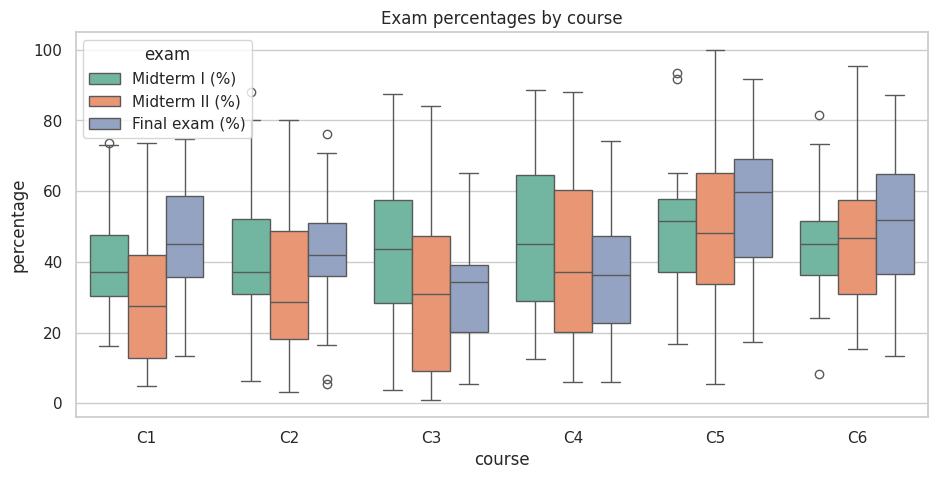

In [13]:
long = df.melt(id_vars="course", value_vars=targets, var_name="exam", value_name="percentage")
long["exam"] = long["exam"].map(titles)

plt.figure(figsize=(11, 5))
sns.boxplot(data=long, x="course", y="percentage", hue="exam", palette="Set2")
plt.title("Exam percentages by course")
plt.show()

**Reading the result:** some courses are clearly harder or easier than others (the boxes sit at different heights). This is one reason why predicting marks is not perfect: the same assignment average can mean different exam results in different courses.

### 4.6 Outliers (IQR rule)

In [14]:
def count_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

out_table = pd.Series({c: count_outliers(df[c]) for c in df.select_dtypes("number").columns},
                      name="outliers").to_frame()
out_table

,outliers
mid1_pct,1
mid2_pct,0
final_pct,0
assign_avg_early,1
quiz_avg_early,0
assign_avg_75,2
quiz_avg_75,0
assign_avg_all,2
quiz_avg_all,0


Very few (or no) outliers. Also, extreme values here are real marks (a student really can score 5% or 95%), so we **keep** all of them.

### 4.7 Correlation between all numeric columns

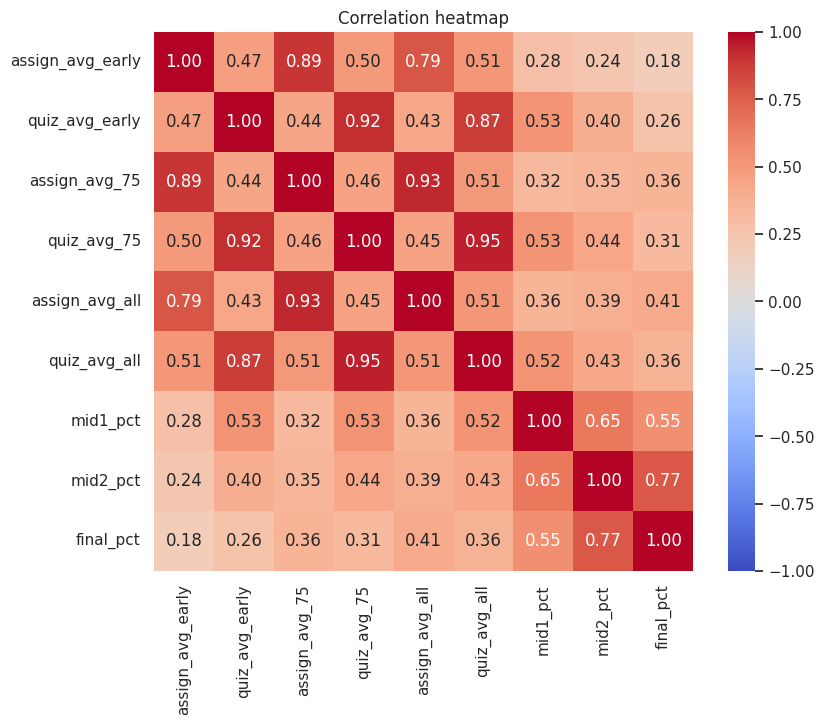

In [15]:
num_cols = ["assign_avg_early", "quiz_avg_early", "assign_avg_75", "quiz_avg_75",
            "assign_avg_all", "quiz_avg_all", "mid1_pct", "mid2_pct", "final_pct"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation heatmap")
plt.show()

**Reading the result:** Midterm I and Midterm II are strongly related to each other, and Midterm II is strongly related to the Final. Quiz and assignment averages are only moderately related to exams. So we expect the *earlier exams* to be the best predictors of later exams.

### 4.8 Scatter plots: each feature against its target (one row per RQ)

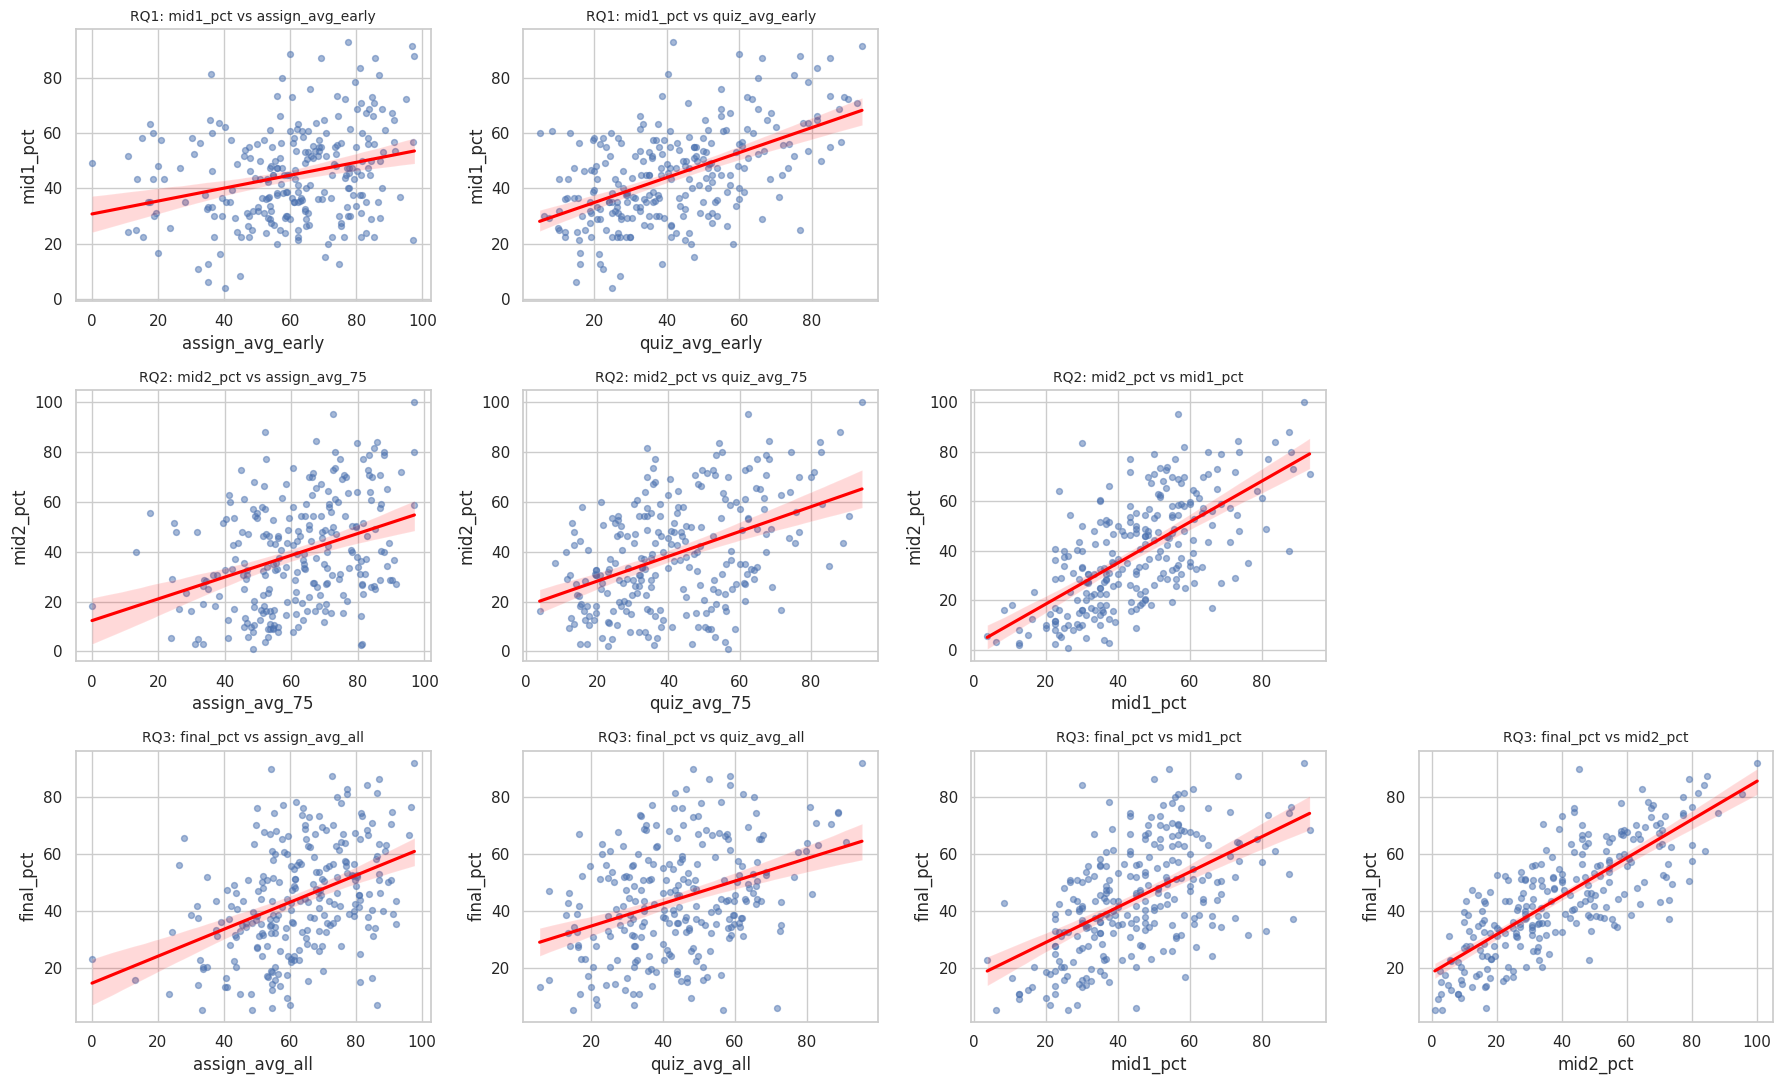

In [16]:
RQS = {
    "RQ1": {"target": "mid1_pct",  "features": ["assign_avg_early", "quiz_avg_early"]},
    "RQ2": {"target": "mid2_pct",  "features": ["assign_avg_75", "quiz_avg_75", "mid1_pct"]},
    "RQ3": {"target": "final_pct", "features": ["assign_avg_all", "quiz_avg_all", "mid1_pct", "mid2_pct"]},
}

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for r, (rq, cfg) in enumerate(RQS.items()):
    for c in range(4):
        ax = axes[r, c]
        if c < len(cfg["features"]):
            f = cfg["features"][c]
            sns.regplot(data=df, x=f, y=cfg["target"], ax=ax, scatter_kws={"alpha": 0.5, "s": 18}, line_kws={"color": "red"})
            ax.set_title(f"{rq}: {cfg['target']} vs {f}", fontsize=10)
        else:
            ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Train / test split and avoiding data leakage

### What is data leakage?
Data leakage means information from the **test data** sneaks into the training process, which makes the results look better than they really are. Typical mistakes:

1. Filling missing values with the mean of the **whole** dataset (the mean includes test rows).
2. Scaling / standardising using the **whole** dataset.
3. Choosing features or model settings by looking at test results.
4. Using a column that would not be known yet (e.g. Midterm II to predict Midterm I).

### How we avoid it in this project
| Risk | Our solution |
|---|---|
| Imputation | `SimpleImputer` lives **inside the Pipeline**, so it learns the median from the training rows only |
| Scaling | `StandardScaler` is also inside the Pipeline (fit on train only) |
| Feature / degree selection | done with **K-fold CV on the training set only** |
| Choosing the best model | based on **CV error (train data)**, not on test error |
| Bootstrapping | samples drawn from **training data only** |
| Time order | each RQ only uses assessments that happened before the exam |

We split **once**, 80% train / 20% test, and stratify by course so every course appears in both parts.

In [17]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_STATE, stratify=df["course"])
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print()
print(pd.concat([train_df["course"].value_counts().rename("train"),
                 test_df["course"].value_counts().rename("test")], axis=1).sort_index())

Train rows: 203 | Test rows: 51

        train  test
course             
C1         27     7
C2         22     6
C3         35     9
C4         37     9
C5         41    10
C6         41    10


## 6. Modelling helpers

For every research question we compare **four kinds of model**:

| Model | Idea |
|---|---|
| **Dummy (baseline)** | always predicts the average training mark. Any real model must beat this. |
| **Simple linear regression** | one predictor only (the one most correlated with the target *in the training set*) |
| **Multiple linear regression** | all allowed predictors |
| **Polynomial regression** | multiple regression + squared/cubic terms. Degree (2, 3 or 4) is chosen with 5-fold CV on the training set |

**Metrics** (all in *percentage points* of the exam):
* **MAE** – average size of the error (easy to understand: "we are off by about X points")
* **RMSE** – like MAE but punishes big mistakes more
* **R²** – share of the variation explained (1 = perfect, 0 = same as predicting the average, negative = worse than the average)

**K-fold CV (5 folds):** the training data is cut into 5 parts; each part takes a turn as a mini-test set. It gives a more stable error estimate.

**Bootstrapping (500 samples):** we resample the training rows with replacement 500 times, fit the model on each resample, and measure MAE on the rows **not** drawn (out-of-bag). The middle 95% of the 500 MAE values (2.5th to 97.5th percentile) is the **95% confidence interval**.

In [18]:
def make_pipeline(degree=1):
    """impute -> scale -> (polynomial) -> linear regression. Everything is fitted on the training data only."""
    steps = [("imputer", SimpleImputer(strategy="median")),
             ("scaler", StandardScaler())]
    if degree > 1:
        steps.append(("poly", PolynomialFeatures(degree=degree, include_bias=False)))
    steps.append(("regression", LinearRegression()))
    return Pipeline(steps)


def get_scores(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred)}


def bootstrap_mae(model, X, y, n_boot=500, seed=RANDOM_STATE):
    """Bootstrap on TRAIN data only. Returns all MAE values and the 95% confidence interval."""
    rng = np.random.default_rng(seed)
    n = len(X)
    maes = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)                     # draw n rows WITH replacement
        oob = np.setdiff1d(np.arange(n), idx)           # rows never drawn = out-of-bag
        if len(oob) == 0:
            continue
        m = clone(model).fit(X.iloc[idx], y.iloc[idx])
        maes.append(mean_absolute_error(y.iloc[oob], m.predict(X.iloc[oob])))
    maes = np.array(maes)
    return maes, np.percentile(maes, [2.5, 97.5])

In [19]:
def run_rq(rq):
    """Train and evaluate all models for one research question."""
    target, features = RQS[rq]["target"], RQS[rq]["features"]

    # Only rows whose TARGET is known can be used (a missing target cannot be predicted or scored).
    # Missing FEATURES are kept: the pipeline imputes them using train medians only.
    tr = train_df.dropna(subset=[target]).reset_index(drop=True)
    te = test_df.dropna(subset=[target]).reset_index(drop=True)
    y_tr, y_te = tr[target], te[target]

    # 1) simple regression: choose the single best feature using TRAIN correlation only
    corr = tr[features + [target]].corr()[target].drop(target)
    simple_feature = corr.abs().idxmax()

    # 2) polynomial: choose the degree with K-fold CV on TRAIN only
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    degree_cv = {}
    for d in (2, 3, 4):
        degree_cv[d] = -cross_val_score(make_pipeline(d), tr[features], y_tr, cv=kf,
                                        scoring="neg_mean_absolute_error").mean()
    best_degree = min(degree_cv, key=degree_cv.get)

    models = {
        "Dummy (mean)":              (DummyRegressor(strategy="mean"), features),
        f"Simple LR ({simple_feature})": (make_pipeline(1), [simple_feature]),
        "Multiple LR":               (make_pipeline(1), features),
        f"Polynomial (deg {best_degree})": (make_pipeline(best_degree), features),
    }

    rows, fitted, boots = [], {}, {}
    for name, (model, feats) in models.items():
        cv_mae = -cross_val_score(model, tr[feats], y_tr, cv=kf, scoring="neg_mean_absolute_error")
        model.fit(tr[feats], y_tr)
        s_tr = get_scores(y_tr, model.predict(tr[feats]))
        s_te = get_scores(y_te, model.predict(te[feats]))
        boot, ci = bootstrap_mae(model, tr[feats], y_tr)
        rows.append({
            "Model": name,
            "CV MAE (5-fold)": f"{cv_mae.mean():.2f} +/- {cv_mae.std():.2f}",
            "Train MAE": round(s_tr["MAE"], 2), "Test MAE": round(s_te["MAE"], 2),
            "Test RMSE": round(s_te["RMSE"], 2), "Test R2": round(s_te["R2"], 3),
            "Bootstrap MAE 95% CI": f"[{ci[0]:.2f}, {ci[1]:.2f}]",
            "_cv": cv_mae.mean(), "_train": s_tr, "_test": s_te,
        })
        fitted[name] = (model, feats)
        boots[name] = boot

    table = pd.DataFrame(rows)
    # best model = lowest CV error (decided on TRAIN data, never on the test set)
    best_name = table.loc[table["_cv"].idxmin(), "Model"]
    return {"rq": rq, "target": target, "features": features, "tr": tr, "te": te,
            "table": table, "fitted": fitted, "boots": boots, "best": best_name,
            "simple_feature": simple_feature, "degree_cv": degree_cv, "best_degree": best_degree, "corr": corr}


def show_rq(res):
    """Print the comparison table and draw the charts for one RQ."""
    shown = res["table"].drop(columns=["_cv", "_train", "_test"])
    print(f"{res['rq']}: predicting {res['target']}  |  train rows = {len(res['tr'])}, test rows = {len(res['te'])}")
    print("Features allowed:", res["features"])
    print(f"Simple regression uses '{res['simple_feature']}' (highest train correlation = {res['corr'][res['simple_feature']]:.2f})")
    print("Polynomial degree CV MAE:", {d: round(float(v), 2) for d, v in res["degree_cv"].items()}, "-> chosen degree", res["best_degree"])
    display(shown.style.hide(axis="index").highlight_min(subset=["Test MAE", "Test RMSE"], color="#c8f7c5")
            .highlight_max(subset=["Test R2"], color="#c8f7c5"))

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    # (a) bootstrap distributions
    names = list(res["boots"].keys())
    axes[0].boxplot([res["boots"][n] for n in names], labels=[n.split(" (")[0] if "Simple" not in n else "Simple LR" for n in names], showmeans=True)
    axes[0].set_title("Bootstrap distribution of MAE (500 resamples, train data)")
    axes[0].set_ylabel("MAE (percentage points)")
    # (b) test MAE bars
    t = res["table"]
    axes[1].bar(range(len(t)), t["Test MAE"], color=["#999", "#6baed6", "#3182bd", "#08519c"])
    axes[1].set_xticks(range(len(t))); axes[1].set_xticklabels([n.split(" (")[0] if "Simple" not in n else "Simple LR" for n in t["Model"]])
    for i, v in enumerate(t["Test MAE"]):
        axes[1].text(i, v + 0.2, f"{v:.2f}", ha="center")
    axes[1].set_title("Test MAE (lower is better)"); axes[1].set_ylabel("MAE (percentage points)")
    plt.tight_layout(); plt.show()


def best_model_report(res):
    """Train vs test scores of the best model + predicted-vs-actual plot."""
    row = res["table"][res["table"]["Model"] == res["best"]].iloc[0]
    tr_s, te_s = row["_train"], row["_test"]
    comp = pd.DataFrame({"Train": tr_s, "Test": te_s}).round(3)
    print(f"Best model for {res['rq']} (lowest 5-fold CV MAE on train data): {res['best']}")
    display(comp)

    gap = tr_s["R2"] - te_s["R2"]
    if tr_s["R2"] < 0.30 and te_s["R2"] < 0.30:
        verdict = ("LOW R2 on both train and test -> the model is UNDERFITTING / the inputs simply carry limited information. "
                   "It is still better than the dummy baseline if its MAE is lower.")
    elif gap > 0.10:
        verdict = "Train R2 is much higher than test R2 -> OVERFITTING."
    else:
        verdict = "Train and test scores are close -> a good fit (no strong over/underfitting)."
    print("Diagnosis:", verdict)

    model, feats = res["fitted"][res["best"]]
    te = res["te"]; pred = model.predict(te[feats])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(te[res["target"]], pred, alpha=0.7)
    lim = [0, 100]
    axes[0].plot(lim, lim, "r--", label="perfect prediction")
    axes[0].set_xlabel("Actual (%)"); axes[0].set_ylabel("Predicted (%)"); axes[0].set_title("Test set: predicted vs actual"); axes[0].legend()
    sns.histplot(te[res["target"]] - pred, kde=True, ax=axes[1], color="steelblue")
    axes[1].axvline(0, color="red", ls="--")
    axes[1].set_title("Test residuals (actual - predicted)"); axes[1].set_xlabel("error (percentage points)")
    plt.tight_layout(); plt.show()


def show_coefficients(res):
    """Coefficients of multiple linear regression (standardised, so they can be compared)."""
    model, feats = res["fitted"]["Multiple LR"]
    coefs = pd.Series(model.named_steps["regression"].coef_, index=feats).sort_values()
    print("Multiple LR coefficients (change in predicted % for a +1 standard-deviation change in that input):")
    display(coefs.round(2).to_frame("coefficient"))
    coefs.plot.barh(color="teal", figsize=(6, 2.5 + 0.3 * len(coefs)), title="Multiple LR – standardised coefficients")
    plt.show()

## 7. Results

### RQ1 – How accurately can we predict **Midterm I** marks?
Allowed inputs: only the **first half** of assignments and quizzes (nothing from Midterm II or the Final, since they happen later).

RQ1: predicting mid1_pct  |  train rows = 203, test rows = 51
Features allowed: ['assign_avg_early', 'quiz_avg_early']
Simple regression uses 'quiz_avg_early' (highest train correlation = 0.53)
Polynomial degree CV MAE: {2: 11.38, 3: 11.66, 4: 11.87} -> chosen degree 2


Model,CV MAE (5-fold),Train MAE,Test MAE,Test RMSE,Test R2,Bootstrap MAE 95% CI
Dummy (mean),13.49 +/- 1.41,13.410000,15.770000,18.750000,-0.003000,"[11.67, 15.47]"
Simple LR (quiz_avg_early),11.23 +/- 0.75,11.140000,13.310000,16.020000,0.268000,"[9.64, 12.93]"
Multiple LR,11.31 +/- 0.82,11.120000,13.320000,16.000000,0.269000,"[9.67, 13.00]"
Polynomial (deg 2),11.38 +/- 0.65,11.000000,13.090000,15.640000,0.302000,"[9.98, 13.17]"


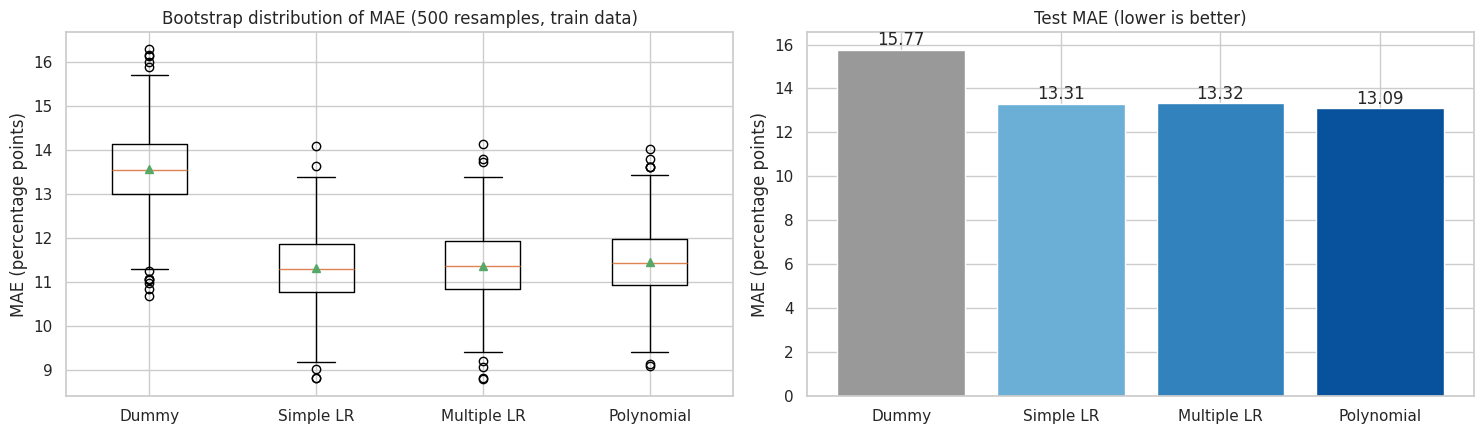

In [20]:
res1 = run_rq("RQ1")
show_rq(res1)

Best model for RQ1 (lowest 5-fold CV MAE on train data): Simple LR (quiz_avg_early)


,Train,Test
MAE,11.144,13.311
RMSE,14.156,16.017
R2,0.283,0.268


Diagnosis: LOW R2 on both train and test -> the model is UNDERFITTING / the inputs simply carry limited information. It is still better than the dummy baseline if its MAE is lower.


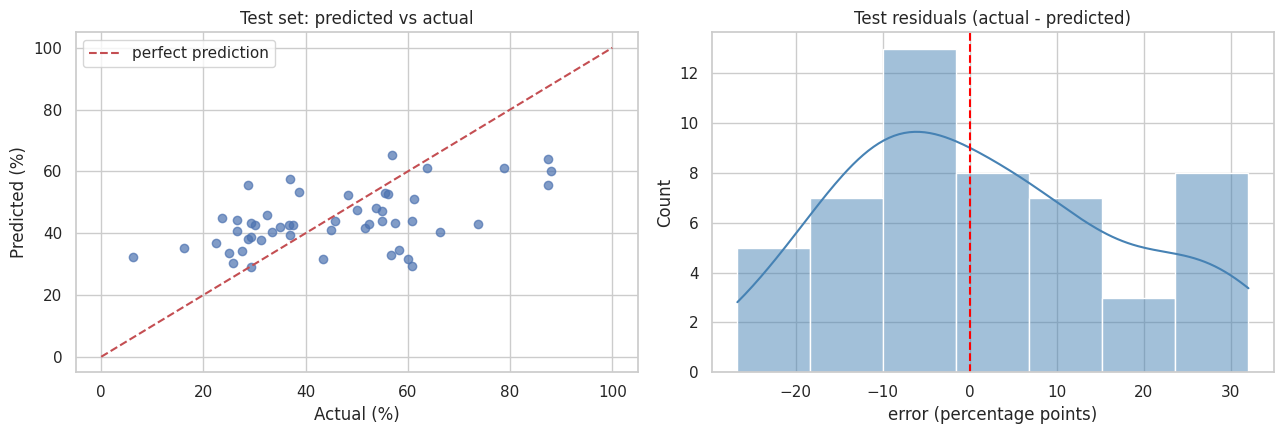

Multiple LR coefficients (change in predicted % for a +1 standard-deviation change in that input):


,coefficient
assign_avg_early,0.39
quiz_avg_early,8.71


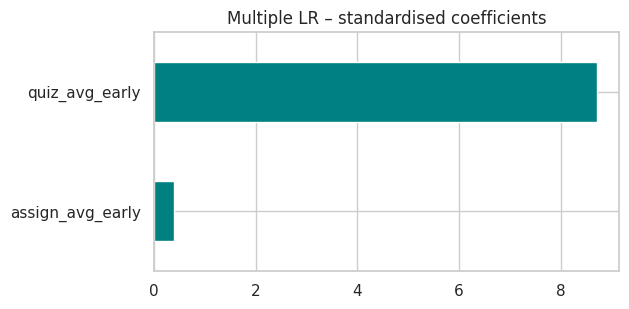

In [21]:
best_model_report(res1)
show_coefficients(res1)

### RQ2 – How accurately can we predict **Midterm II** marks?
Allowed inputs: the first 75% of assignments and quizzes **and Midterm I** (it happened earlier).

RQ2: predicting mid2_pct  |  train rows = 200, test rows = 51
Features allowed: ['assign_avg_75', 'quiz_avg_75', 'mid1_pct']
Simple regression uses 'mid1_pct' (highest train correlation = 0.65)
Polynomial degree CV MAE: {2: 14.13, 3: 15.06, 4: 14.81} -> chosen degree 2


Model,CV MAE (5-fold),Train MAE,Test MAE,Test RMSE,Test R2,Bootstrap MAE 95% CI
Dummy (mean),18.55 +/- 1.93,18.430000,17.240000,21.120000,-0.012000,"[16.38, 21.03]"
Simple LR (mid1_pct),13.97 +/- 0.55,13.650000,12.490000,15.670000,0.443000,"[11.84, 15.80]"
Multiple LR,13.84 +/- 0.59,13.560000,12.060000,15.250000,0.472000,"[12.00, 15.89]"
Polynomial (deg 2),14.13 +/- 0.96,13.260000,12.490000,15.630000,0.446000,"[12.16, 16.34]"


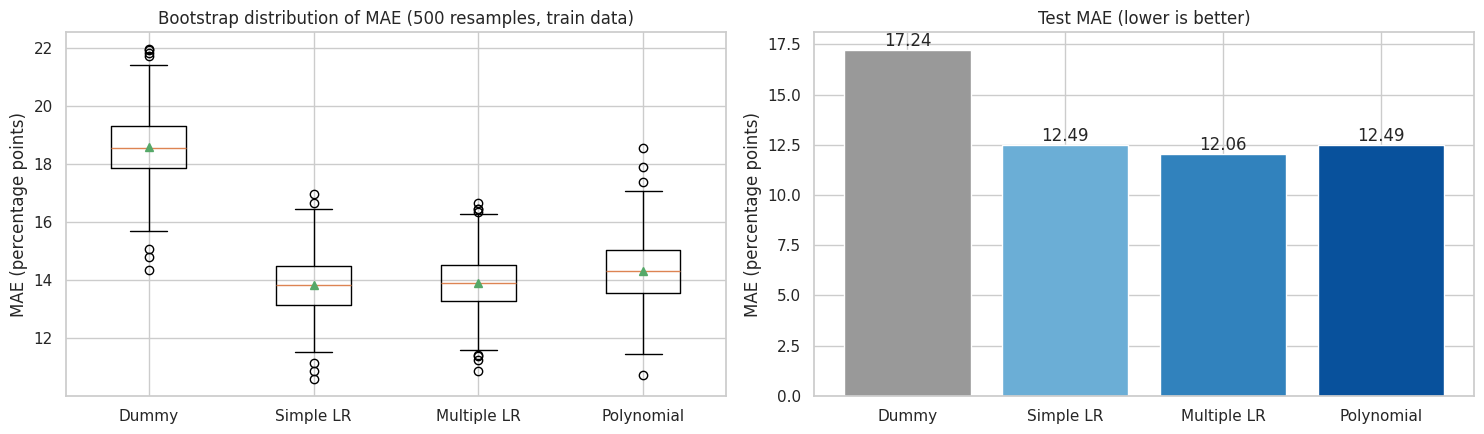

In [22]:
res2 = run_rq("RQ2")
show_rq(res2)

Best model for RQ2 (lowest 5-fold CV MAE on train data): Multiple LR


,Train,Test
MAE,13.557,12.057
RMSE,16.348,15.253
R2,0.442,0.472


Diagnosis: Train and test scores are close -> a good fit (no strong over/underfitting).


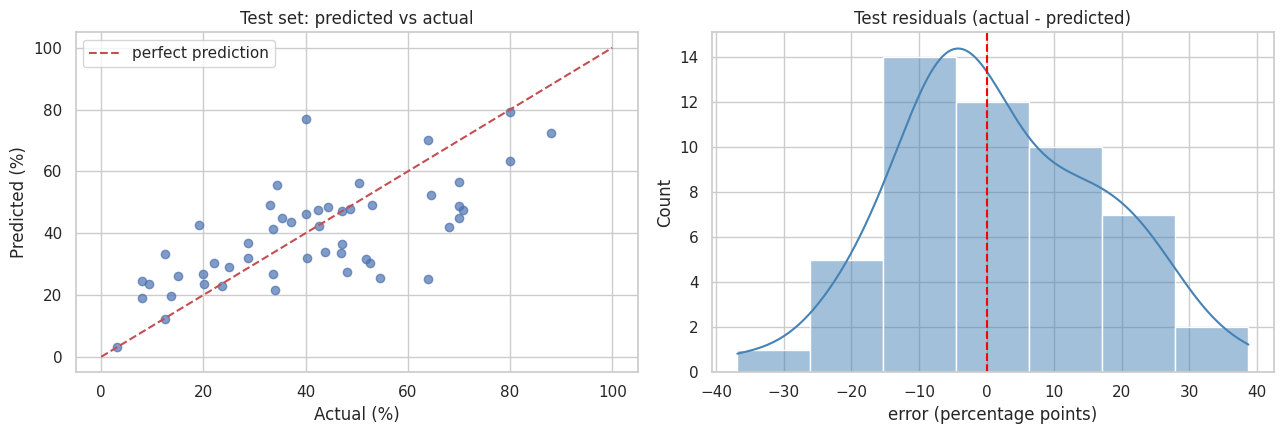

Multiple LR coefficients (change in predicted % for a +1 standard-deviation change in that input):


,coefficient
quiz_avg_75,1.43
assign_avg_75,2.91
mid1_pct,12.47


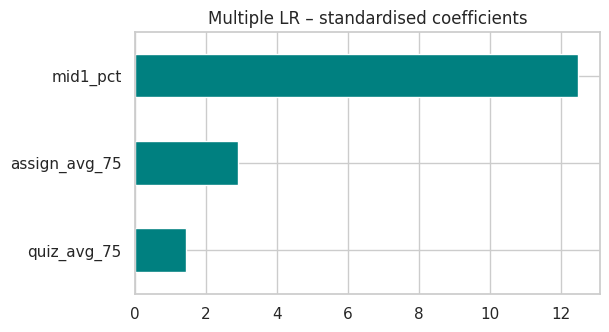

In [23]:
best_model_report(res2)
show_coefficients(res2)

### RQ3 – How accurately can we predict the **Final exam** marks?
Allowed inputs: all assignments and quizzes, plus **Midterm I and Midterm II**.

RQ3: predicting final_pct  |  train rows = 203, test rows = 51
Features allowed: ['assign_avg_all', 'quiz_avg_all', 'mid1_pct', 'mid2_pct']
Simple regression uses 'mid2_pct' (highest train correlation = 0.78)
Polynomial degree CV MAE: {2: 10.68, 3: 11.01, 4: 14.49} -> chosen degree 2


Model,CV MAE (5-fold),Train MAE,Test MAE,Test RMSE,Test R2,Bootstrap MAE 95% CI
Dummy (mean),15.58 +/- 0.91,15.530000,15.620000,19.190000,-0.012000,"[13.63, 17.53]"
Simple LR (mid2_pct),10.15 +/- 1.09,9.970000,9.890000,12.470000,0.573000,"[8.84, 11.31]"
Multiple LR,10.21 +/- 1.24,9.840000,9.080000,11.770000,0.619000,"[8.90, 11.33]"
Polynomial (deg 2),10.68 +/- 1.24,9.460000,8.870000,11.290000,0.650000,"[9.06, 12.11]"


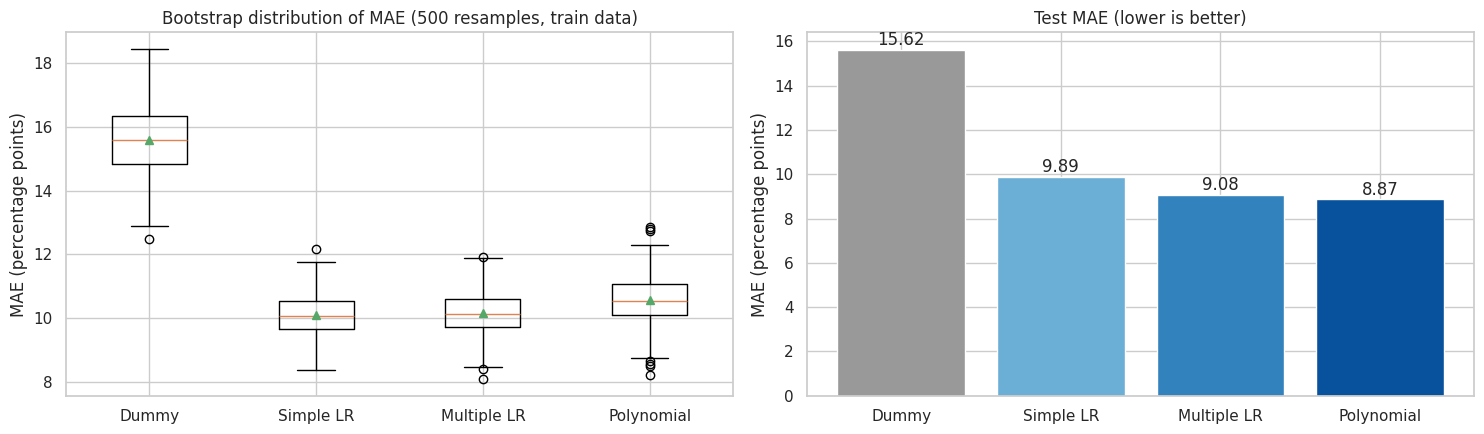

In [24]:
res3 = run_rq("RQ3")
show_rq(res3)

Best model for RQ3 (lowest 5-fold CV MAE on train data): Simple LR (mid2_pct)


,Train,Test
MAE,9.973,9.886
RMSE,12.292,12.468
R2,0.584,0.573


Diagnosis: Train and test scores are close -> a good fit (no strong over/underfitting).


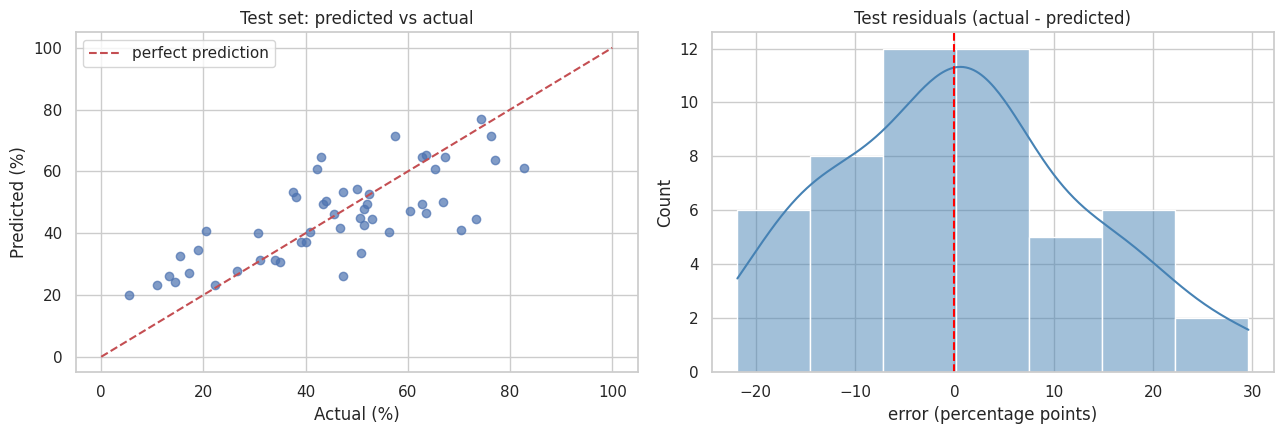

Multiple LR coefficients (change in predicted % for a +1 standard-deviation change in that input):


,coefficient
quiz_avg_all,-0.63
mid1_pct,1.06
assign_avg_all,2.45
mid2_pct,13.19


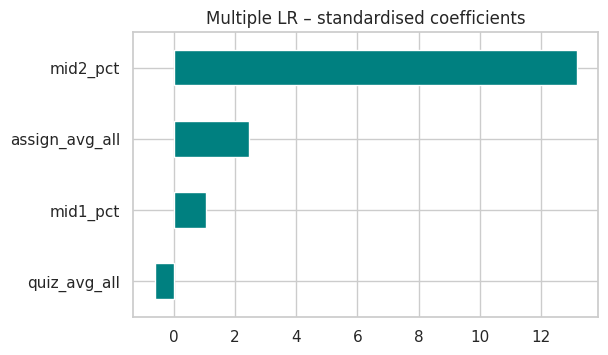

In [25]:
best_model_report(res3)
show_coefficients(res3)

## 8. Final summary across all research questions

,RQ,Model,CV MAE (5-fold),Train MAE,Test MAE,Test RMSE,Test R2,Bootstrap MAE 95% CI
0,RQ1,Dummy (mean),13.49 +/- 1.41,13.41,15.77,18.75,-0.003,"[11.67, 15.47]"
1,RQ1,Simple LR (quiz_avg_early),11.23 +/- 0.75,11.14,13.31,16.02,0.268,"[9.64, 12.93]"
2,RQ1,Multiple LR,11.31 +/- 0.82,11.12,13.32,16.00,0.269,"[9.67, 13.00]"
3,RQ1,Polynomial (deg 2),11.38 +/- 0.65,11.00,13.09,15.64,0.302,"[9.98, 13.17]"
4,RQ2,Dummy (mean),18.55 +/- 1.93,18.43,17.24,21.12,-0.012,"[16.38, 21.03]"
5,RQ2,Simple LR (mid1_pct),13.97 +/- 0.55,13.65,12.49,15.67,0.443,"[11.84, 15.80]"
6,RQ2,Multiple LR,13.84 +/- 0.59,13.56,12.06,15.25,0.472,"[12.00, 15.89]"
7,RQ2,Polynomial (deg 2),14.13 +/- 0.96,13.26,12.49,15.63,0.446,"[12.16, 16.34]"
8,RQ3,Dummy (mean),15.58 +/- 0.91,15.53,15.62,19.19,-0.012,"[13.63, 17.53]"
9,RQ3,Simple LR (mid2_pct),10.15 +/- 1.09,9.97,9.89,12.47,0.573,"[8.84, 11.31]"


,RQ,Best model,Train MAE,Test MAE,Train R2,Test R2,Dummy Test MAE,Improvement over dummy (MAE points)
0,RQ1,Simple LR (quiz_avg_early),11.14,13.31,0.283,0.268,15.77,2.46
1,RQ2,Multiple LR,13.56,12.06,0.442,0.472,17.24,5.18
2,RQ3,Simple LR (mid2_pct),9.97,9.89,0.584,0.573,15.62,5.73


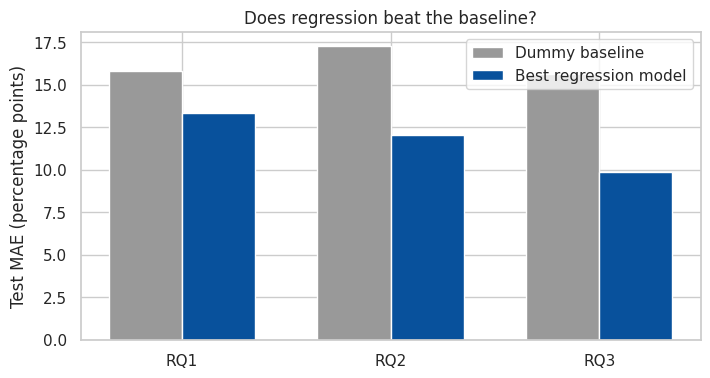

In [26]:
all_res = {"RQ1": res1, "RQ2": res2, "RQ3": res3}
summary_rows = []
for rq, res in all_res.items():
    t = res["table"].drop(columns=["_cv", "_train", "_test"]).copy()
    t.insert(0, "RQ", rq)
    summary_rows.append(t)
summary = pd.concat(summary_rows, ignore_index=True)
display(summary)

# Best model per RQ: train vs test, side by side
best_rows = []
for rq, res in all_res.items():
    row = res["table"][res["table"]["Model"] == res["best"]].iloc[0]
    dummy = res["table"].iloc[0]
    best_rows.append({"RQ": rq, "Best model": res["best"],
                      "Train MAE": round(row["_train"]["MAE"], 2), "Test MAE": round(row["_test"]["MAE"], 2),
                      "Train R2": round(row["_train"]["R2"], 3), "Test R2": round(row["_test"]["R2"], 3),
                      "Dummy Test MAE": dummy["Test MAE"],
                      "Improvement over dummy (MAE points)": round(dummy["Test MAE"] - row["_test"]["MAE"], 2)})
best_df = pd.DataFrame(best_rows)
display(best_df)

# chart: dummy vs best model test MAE for each RQ
x = np.arange(3); w = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, best_df["Dummy Test MAE"], w, label="Dummy baseline", color="#999")
plt.bar(x + w/2, best_df["Test MAE"], w, label="Best regression model", color="#08519c")
plt.xticks(x, best_df["RQ"]); plt.ylabel("Test MAE (percentage points)")
plt.title("Does regression beat the baseline?"); plt.legend()
plt.show()

### Interpretation of the findings

**Overall answer to the three research questions** (numbers are MAE / R² on the held-out test set; MAE is in percentage points of the exam):

* **RQ1 – Midterm I is the hardest to predict.** The best model (simple regression on the early quiz average) has a test MAE of about 13.3 points and R² of about 0.27, versus 15.8 points and R² of about 0 for the dummy baseline. Only the early quizzes and assignments are available before Midterm I, and they explain roughly a quarter of the variation. In the multiple regression the quiz average has a much larger coefficient than the assignment average, so quizzes are the more useful signal.
* **RQ2 – Midterm II is predicted moderately well.** The best model (multiple regression) reaches a test MAE of about 12.1 points and R² of about 0.47, compared with 17.2 points for the dummy. The dominant predictor is Midterm I: students who did well in Midterm I tend to do well in Midterm II.
* **RQ3 – The Final exam is the easiest to predict.** The best model by cross-validation (simple regression on Midterm II) has a test MAE of about 9.9 points and R² of about 0.57, versus 15.6 points for the dummy. Midterm II carries most of the information; assignments and quizzes add very little once the midterms are known. Multiple and polynomial regression scored slightly better on the test set (MAE about 9.1 and 8.9), but they were not better in cross-validation, so with only 51 test rows we treat that difference as noise.

**Baseline comparison.** In all three RQs every regression model beats the dummy model on MAE, RMSE and R² (the dummy always has R² close to 0). The size of the improvement grows as more past information becomes available: about 2.5 points for RQ1, 5.2 for RQ2 and 5.7 for RQ3.

**Bootstrap 95% confidence intervals.** The intervals show how much the MAE would change with a different sample of students. For RQ2 and RQ3 the regression intervals sit clearly below the dummy intervals (little overlap), so the improvement is reliable. For RQ1 the intervals overlap a lot (roughly 9.7-13.0 vs 11.7-15.5), so the improvement over the baseline is real on average but less certain.

**Over/underfitting.** For the best models, train and test scores are close, so there is no strong overfitting. In RQ1 the R² is low on both train and test, meaning the model is limited by how little the inputs say about Midterm I (the error is not caused by memorising the training data). For polynomial regression, the cross-validation MAE printed above each table gets worse as the degree grows (for example RQ3: 10.68 at degree 2, 11.01 at degree 3 and 14.49 at degree 4). Higher degrees fit the training data more closely but generalise worse, which is classic overfitting, and this is why the degree is chosen by cross-validation on the training data and degree 2 was selected every time.

**Limitations.** (1) The dataset is small (254 students), so results can move a little with a different split. (2) The files have no dates, so "which assessments came before an exam" is an assumption (50% / 75% / 100%). (3) Course difficulty differs, which adds unexplained variation. (4) A predictor like course ID or attendance could improve accuracy but is not in the data.

## 9. Save the deliverables
* `preprocessed_dataset.csv` – the combined, cleaned dataset used for model fitting (with a `split` column saying train/test). Remaining empty cells are filled **inside the pipeline using train medians only**, so they are left empty here on purpose to avoid leakage.
* `results_summary.csv` – the comparison table of all models.
* `workflow_pipeline.png` – the workflow diagram (already saved above).

In [27]:
final_data = pd.concat([train_df.assign(split="train"), test_df.assign(split="test")], ignore_index=True)
final_data.to_csv("preprocessed_dataset.csv", index=False)
summary.to_csv("results_summary.csv", index=False)
print("Saved preprocessed_dataset.csv", final_data.shape)
print("Saved results_summary.csv", summary.shape)

Saved preprocessed_dataset.csv (254, 12)
Saved results_summary.csv (12, 8)


### Dashboard (Deliverable 3)
A Streamlit dashboard is provided in `app.py`. To run it:
```
pip install streamlit pandas numpy scikit-learn matplotlib seaborn
streamlit run app.py
```
Keep `app.py`, `preprocessed_dataset.csv` and `workflow_pipeline.png` in the same folder.